# Preprocessing x sensor placement -> latent space

What the AER actually sees is `client_datasets` -> `preprocess_clients` -> `(N, W, F)` windows.
Two things upstream of that are still unexamined: **where** the channels come from (placement,
never wired into the FL path) and **what** is done to them in time (aggregation, windowing,
scaling, and transforms we do not apply at all).

This notebook makes both axes explicit and scores them on the same two questions:

| block | what it answers |
|---|---|
| SS.2-4 | what am I feeding the model? (widget: raw -> transformed -> aggregated -> scaled window) |
| SS.5 | what is not applied yet, and does it change the input statistics at all (no training) |
| SS.6-7 | grid `placement x preprocessing` on ONE world, scored on latent + drift |
| SS.8 | the same grid across worlds; the ranking only counts if it replicates |

Rules kept from the two source notebooks: `preprocess_clients` and `FPLTrainer` are imported and
never re-implemented; placement enters as a **column selection**, no re-simulation; ground truth
(`drift_district`, `gt_drift_schedule`) enters at scoring time only.

## 0. Setup

In [1]:
from __future__ import annotations
import copy, itertools, pathlib, sys, time, warnings

import numpy as np, pandas as pd, torch, yaml
warnings.filterwarnings("ignore")

HERE = pathlib.Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents]
             if (p / "conf" / "base" / "parameters.yml").exists()
             and (p / "src" / "fedwater").is_dir()), None)
assert ROOT is not None, "run this from inside the fedwater repo (notebooks/...)"
for p in (ROOT / "src", ROOT / "notebooks", ROOT, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from notebooks.SensorPlacement import placement_poc as P                   # the placement POC, imported not copied
from fedwater.pipelines.fl_preprocessing.nodes import preprocess_clients
from fedwater.pipelines.fl_training.federated import FPLTrainer
from fedwater.pipelines.fl_training.nodes import effective_fl_seed
from fedwater.pipelines.drift_detection.nodes import compute_drift_signals
from fedwater.pipelines.dependence_oracle.nodes import deseasonalize

BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
SEED   = BASE_PARAMS.get("seed", 42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT    = HERE / "prep_grid"; OUT.mkdir(exist_ok=True)
pd.set_option("display.width", 170)

print(f"root {ROOT}\ndevice {DEVICE}  seed {SEED}  out {OUT}")

root C:\Users\arthu\USPy\10_Mestrado\fedWater
device cuda  seed 42  out C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\prep_grid


## 1. World and configuration

`discover_worlds` reads the experiments cache directly. Only `baseline` worlds are used: under
`partial`/`isolated` a topology-driven placement sees the same pipes the labels come from.

In [2]:
index = P.discover_worlds(ROOT)
assert len(index) and index["usable"].any(), "no usable cached worlds"
usable = index[index["usable"] & (index["variant"] == "baseline")]
display(usable[["tag", "sim_seed", "consumption_map", "n_months", "drift_district"]]
        .reset_index(drop=True))

WORLD = usable.iloc[73]                       # <- the single-world study
ART   = P.load_world(WORLD["dir"])
TIME  = ART["params"]["time"]
STEPS_DAY   = ART["steps_day"]
FL_BASE     = copy.deepcopy(ART["params"].get("fl", BASE_PARAMS["fl"]))
FL_BASE["training"]["device"] = DEVICE
TRUTH_CLIENT = WORLD.get("drift_district")


def drift_start(world_dir, n_months) -> int:
    """First drifted month, from gt_drift_schedule; midpoint if absent."""
    f = pathlib.Path(world_dir) / "clone" / "data" / "03_primary" / "gt_drift_schedule.csv"
    if f.exists():
        d = pd.read_csv(f)
        col = next((c for c in d.columns if "month" in c.lower()), None)
        if col is not None and len(d):
            v = pd.to_numeric(d[col], errors="coerce").dropna()
            if len(v):
                return int(v.min())
    return int(n_months) // 2


DRIFT_START = drift_start(WORLD["dir"], TIME["n_months"])
print(f"{WORLD['tag']}  |  drift {TRUTH_CLIENT} from month {DRIFT_START}  |  "
      f"{TIME['n_months']} months @ {TIME['resolution_h']}h  |  steps/day {STEPS_DAY}")

,tag,sim_seed,consumption_map,n_months,drift_district
0,Cli__LR_LR_LR_LR_LI__baseline,42,LR_LR_LR_LR_LI,48,District_C
1,Dlr__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_D
2,Cli__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_C
3,Dlr__LR_LR_LR_LI_LI__baseline,42,LR_LR_LR_LI_LI,48,District_D
4,Clc__LR_LI_LI_LC_LR__baseline,42,LR_LI_LI_LC_LR,30,District_C
...,...,...,...,...,...
83,Bli__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_B
84,Elr__LR_LR_LR_LR_HR__baseline,44,LR_LR_LR_LR_HR,48,District_E
85,Elr__LR_LR_LR_LR_LI__baseline,43,LR_LR_LR_LR_LI,48,District_E
86,Elr__LR_LR_LR_LR_LI__baseline,42,LR_LR_LR_LR_LI,48,District_E


Dli__LI_LR_LR_LR_LI__baseline  |  drift District_D from month 6  |  30 months @ 1h  |  steps/day 24


## 2. Placement -> client datasets

`strategies()` returns a placement per rule; `build_series()` turns it into the sensor long frame.
The only new code is the repackaging into the wide `District_*.csv` schema
(`timestamp, month, p_*, q_*`) that `preprocess_clients` consumes -- this is the join that was
missing between the placement POC and the FL stack.

In [3]:
STRATEGIES = ["manual", "variance", "boundary"]      # per the placement POC finding

cands       = P.candidate_table(ART["wn"], ART["districts"])
feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
stats       = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
PLACEMENTS  = {k: v for k, v in
               P.strategies(cands, feats, stats, dist, ART["params"], seed=SEED).items()
               if k in STRATEGIES}


def clients_from_placement(art, placement, noise=False, seed=SEED, kinds=None) -> dict[str, pd.DataFrame]:
    """placement -> {district: wide frame}. kinds: subset of {"pressure","flow"} to keep; None = all."""
    ss = P.build_series(art["pressures"], art["flows"], placement,
                        art["params"]["noise"] if noise else None, seed)
    if kinds:
        ss = ss[ss["kind"].isin(kinds)]
    wide  = ss.pivot(index="step", columns="sensor", values="observed").sort_index()
    month = ss.drop_duplicates("step").set_index("step")["month"].sort_index()
    key   = ss.drop_duplicates("sensor").set_index("sensor")["district"]
    res_h = art["params"]["time"]["resolution_h"]
    ts    = pd.date_range("2020-01-01", periods=len(wide), freq=f"{int(res_h)}h")

    out = {}
    for d, grp in key.groupby(key):
        cols = sorted(grp.index)                       # p_* then q_*, stable across clients
        f = wide[cols].copy().reset_index(drop=True)
        f.insert(0, "month", month.to_numpy())
        f.insert(0, "timestamp", ts)
        out[d] = f
    return out


CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",)) for s, pl in PLACEMENTS.items()}
CHANNELS = {s: {c: [x for x in f.columns if x not in ("timestamp", "month")]
                for c, f in d.items()} for s, d in CLIENTS.items()}
pd.DataFrame({s: {c: ",".join(v) for c, v in ch.items()} for s, ch in CHANNELS.items()})

,manual,variance,boundary
District_A,"q_100,q_102,q_85","q_102,q_103,q_136","q_103,q_104,q_176"
District_B,"q_135,q_157,q_165","q_129,q_131,q_134","q_133,q_134,q_136"
District_C,"q_110,q_119,q_91","q_104,q_119,q_97","q_129,q_95,q_97"
District_D,"q_38,q_69,q_96","q_45,q_94,q_96","q_44,q_69,q_96"
District_E,"q_11,q_19,q_59","q_145,q_53,q_67","q_181,q_65,q_67"


## 3. The preprocessing stack

Two insertion points, deliberately kept apart:

* **before windowing** -- a transform on the client frame (`none | slog | diff | deseason_own |
  deseason_shared`). `preprocess_clients` then runs verbatim on the transformed frame.
* **after windowing** -- the scaling axis. `preprocess_clients` always fits a per-client MinMax
  on the commissioning months; `rescale_windows` inverts that affine map with `fl_scalers` and
  re-applies whatever we asked for, so `none` (physical units) and `zscore` are reachable
  without forking pipeline code.

In [5]:
def _cell_index(n, steps_day, month):
    day = np.arange(n) // steps_day
    return pd.DataFrame({"month": np.asarray(month), "hour": np.arange(n) % steps_day,
                         "weekend": (day % 7) >= 5})


def _slog(x):                       # flows are signed -- log1p on the magnitude
    return np.sign(x) * np.log1p(np.abs(x))


def deseason_shared(frames: dict, steps_day: int, k: int = 4) -> dict:
    """Remove the top-k PCs of the POOLED (month,hour,weekend) profile matrix.

    Each component is mean-zero across cells by construction, so a channel's own LEVEL
    survives -- the difference from `deseason_own`, which subtracts each channel's own cell
    means and therefore deletes exactly the level ladder the regime codes assert.
    """
    cols = {c: [x for x in f.columns if x not in ("timestamp", "month")] for c, f in frames.items()}
    any_f = next(iter(frames.values()))
    cells = _cell_index(len(any_f), steps_day, any_f["month"].to_numpy())
    gid = cells.groupby(["month", "hour", "weekend"], sort=True).ngroup().to_numpy()
    ncell = gid.max() + 1

    stack, names = [], []
    for c, f in frames.items():
        for x in cols[c]:
            v = f[x].to_numpy(float)
            stack.append(np.bincount(gid, v, ncell) / np.bincount(gid, minlength=ncell))
            names.append((c, x))
    Pm = np.column_stack(stack)                              # cells x channels
    mu, sd = Pm.mean(0), Pm.std(0, ddof=0)
    Z = (Pm - mu) / np.where(sd > 0, sd, 1.0)
    U, _, _ = np.linalg.svd(Z, full_matrices=False)
    B = U[:, :k]
    fitted = (B @ (B.T @ Z)) * np.where(sd > 0, sd, 1.0)     # channel units, mean-zero over cells

    out = {c: f.copy() for c, f in frames.items()}
    for j, (c, x) in enumerate(names):
        out[c][x] = out[c][x].to_numpy(float) - fitted[gid, j]
    return out


def apply_transform(frames: dict, name: str, steps_day: int) -> dict:
    if name == "none":
        return frames
    if name == "deseason_shared":
        return deseason_shared(frames, steps_day)
    out = {}
    for c, f in frames.items():
        g = f.copy()
        cols = [x for x in g.columns if x not in ("timestamp", "month")]
        if name == "slog":
            g[cols] = _slog(g[cols].to_numpy(float))
        elif name == "diff":
            g[cols] = g[cols].diff().fillna(0.0)
        elif name == "deseason_own":            # fedwater invariant 5, month-aware
            wide = g[cols].copy()
            wide.index = np.arange(len(g))
            res = deseasonalize(wide, steps_day, g["month"].copy(), month_aware=True)
            g[cols] = np.asarray(res)
        else:
            raise KeyError(name)
        out[c] = g
    return out


TRANSFORMS = ["none", "slog", "diff", "deseason_own", "deseason_shared"]

In [6]:
def _scaler_bounds(scalers: pd.DataFrame, client: str, sensors) -> tuple[np.ndarray, np.ndarray]:
    """(min, max) per channel from fl_scalers, whatever it calls its columns."""
    low = {c.lower(): c for c in scalers.columns}
    ccol = next(low[k] for k in ("district", "client", "partition", "name") if k in low)
    scol = next(low[k] for k in ("sensor", "feature", "channel", "column") if k in low)
    mncol = next(c for c in scalers.columns if "min" in c.lower())
    mxcol = next(c for c in scalers.columns if "max" in c.lower())
    g = scalers[scalers[ccol] == client].drop_duplicates(scol).set_index(scol)
    return (g.loc[list(sensors), mncol].to_numpy(float),
            g.loc[list(sensors), mxcol].to_numpy(float))


def rescale_windows(fl_windows: dict, scalers: pd.DataFrame, mode: str, fl: dict) -> dict:
    """minmax_ref (as-is) | none (physical units) | zscore (per client-channel)."""
    if mode == "minmax_ref":
        return fl_windows
    lo, hi = fl["preprocessing"]["feature_range"]
    out = {}
    for c, d in fl_windows.items():
        mn, mx = _scaler_bounds(scalers, c, d["sensors"])
        raw = (d["windows"].astype(np.float64) - lo) / (hi - lo) * (mx - mn) + mn
        if mode == "none":
            w = raw
        elif mode == "zscore":
            ref = d["labels"] < fl["preprocessing"]["reference_months"]
            src = raw[ref] if ref.any() else raw
            mu = src.reshape(-1, src.shape[-1]).mean(0)
            sd = src.reshape(-1, src.shape[-1]).std(0)
            w = (raw - mu) / np.where(sd > 0, sd, 1.0)
        else:
            raise KeyError(mode)
        out[c] = {**d, "windows": w.astype(np.float32)}
    return out


SCALINGS = ["minmax_ref", "none", "zscore"]

_WIN_CACHE: dict = {}


def build_windows(strategy: str, transform: str, prep: dict, clients=None, cap=None):
    """(fl_windows, scalers, fl_cfg) for one (placement, transform, prep params) cell."""
    key = (strategy, transform, tuple(sorted(prep.items())), tuple(clients or ()), cap)
    if key in _WIN_CACHE:
        return _WIN_CACHE[key]
    fl = copy.deepcopy(FL_BASE)
    fl["preprocessing"].update(prep)
    frames = CLIENTS[strategy]
    if clients:
        frames = {c: frames[c] for c in clients}
    frames = apply_transform(frames, transform, STEPS_DAY)
    fw, sc, _ = preprocess_clients(frames, fl, TIME)
    if cap:
        for c, d in fw.items():
            n = len(d["windows"])
            if n > cap:
                i = np.linspace(0, n - 1, cap).round().astype(int)
                d["windows"], d["labels"] = d["windows"][i], d["labels"][i]
                d["window_start_step"] = d["window_start_step"][i]
    _WIN_CACHE[key] = (fw, sc, fl)
    return _WIN_CACHE[key]


PREP_BASE = dict(interval_agg_h=FL_BASE["preprocessing"]["interval_agg_h"],
                 window_size=FL_BASE["preprocessing"]["window_size"],
                 step_size=FL_BASE["preprocessing"]["step_size"])

fw, sc, _fl = build_windows("manual", "none", PREP_BASE)
print("base cell:", {c: d["windows"].shape for c, d in fw.items()})
inv = rescale_windows(fw, sc, "none", _fl)
c0 = next(iter(fw))
print(f"inversion check ({c0}) -- physical range "
      f"{inv[c0]['windows'].min():.3f}..{inv[c0]['windows'].max():.3f}  "
      f"vs scaled {fw[c0]['windows'].min():.2f}..{fw[c0]['windows'].max():.2f}")

base cell: {'District_A': (9528, 84, 3), 'District_B': (9528, 84, 3), 'District_C': (9528, 84, 3), 'District_D': (9528, 84, 3), 'District_E': (9528, 84, 3)}
inversion check (District_A) -- physical range 0.527..13.689  vs scaled -1.07..1.15


## 4. What am I feeding the model?

Pick 2-3 clients, a channel, the preprocessing parameters, and scrub the window index. Rows:

1. **client series** after the transform, with the selected window shaded -- the full context.
2. **the window the model sees**, one line per client, in whatever units the scaling leaves.

Windows are rebuilt on change for the selected clients only, and cached.

In [28]:
import ipywidgets as W
import matplotlib.pyplot as plt
from IPython.display import display

ALL_CLIENTS = sorted(CLIENTS["manual"])
_c = W.SelectMultiple(options=ALL_CLIENTS, value=tuple(ALL_CLIENTS[:3]), rows=5,
                      description="clients")
_s = W.Dropdown(options=STRATEGIES, value="manual", description="placement")
_t = W.Dropdown(options=TRANSFORMS, value="none", description="transform")
_k = W.Dropdown(options=SCALINGS, value="minmax_ref", description="scaling")
_a = W.Dropdown(options=[1, 2, 3, 4, 6, 8], value=PREP_BASE["interval_agg_h"], description="agg h")
_w = W.Dropdown(options=[12, 24, 48, 84, 168], value=PREP_BASE["window_size"], description="window")
_p = W.Dropdown(options=[1, 3, 6, 12, 24], value=PREP_BASE["step_size"], description="stride")
_ch = W.Dropdown(options=["ch 0", "ch 1", "ch 2"], value="ch 0", description="channel")
_i = W.IntSlider(value=0, min=0, max=100, step=1, description="window", continuous_update=False,
                 layout=W.Layout(width="95%"))
_o = W.Output()


def _draw(*_):
    clients = list(_c.value)[:3]
    if not clients:
        return
    prep = dict(interval_agg_h=_a.value, window_size=_w.value, step_size=_p.value)
    try:
        fw, sc, fl = build_windows(_s.value, _t.value, prep, clients=tuple(clients))
        fw = rescale_windows(fw, sc, _k.value, fl)
    except Exception as err:
        with _o:
            _o.clear_output(wait=True); print(f"{type(err).__name__}: {err}")
        return

    j = int(_ch.value.split()[1])
    n = min(len(fw[c]["windows"]) for c in clients)
    _i.max = n - 1
    idx = min(_i.value, n - 1)
    src = apply_transform({c: CLIENTS[_s.value][c] for c in clients}, _t.value, STEPS_DAY)

    with _o:
        _o.clear_output(wait=True)
        fig, ax = plt.subplots(2, 1, figsize=(12, 6),
                               gridspec_kw={"height_ratios": [2, 1]})
        for c in clients:
            d, f = fw[c], src[c]
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            jj = min(j, len(cols) - 1)
            ax[0].plot(f[cols[jj]].to_numpy(), lw=.4, alpha=.75,
                       label=f"{c} · {cols[jj]}")
            start = int(d["window_start_step"][idx])
            span = _w.value * _a.value // int(TIME["resolution_h"])
            ax[0].axvspan(start, start + span, color="k", alpha=.10)
            ax[1].plot(d["windows"][idx, :, jj], lw=1.2, marker=".", ms=3, label=c)
        ax[0].legend(fontsize=7, ncol=3); ax[0].set_title(
            f"{_s.value} · {_t.value} · agg {_a.value}h · window {_w.value} · stride {_p.value}"
            f"  |  {n} windows/client")
        ax[1].set_title(f"window {idx} as the model sees it ({_k.value})"); ax[1].legend(fontsize=7)
        for a in ax:
            a.grid(alpha=.25)
        fig.tight_layout(); plt.show()

        rows = [{"client": c, "windows": len(fw[c]["windows"]),
                 "shape": str(fw[c]["windows"].shape[1:]),
                 "min": float(fw[c]["windows"].min()), "max": float(fw[c]["windows"].max()),
                 "std": float(fw[c]["windows"].std())} for c in clients]
        display(pd.DataFrame(rows).round(3))


for ctl in (_c, _s, _t, _k, _a, _w, _p, _ch, _i):
    ctl.observe(_draw, names="value")
display(W.VBox([W.HBox([_c, W.VBox([_s, _t, _k]), W.VBox([_a, _w, _p, _ch])]), _i, _o]))
_draw()

# Dli__LI_LR_LR_LR_LI__baseline 

## 5. What we are not applying yet

`fl_preprocessing` currently does: hourly -> `interval_agg_h` aggregation -> sliding window ->
per-client MinMax fitted on the commissioning months. Nothing else. Four candidates, and the
reason each is not obviously right:

| axis | what it does | why it might help | what it costs |
|---|---|---|---|
| `slog` | signed `log1p` | compresses the peaky low-density profiles; the demand ladder is multiplicative | flattens exactly the amplitude that distinguishes regimes |
| `diff` | first difference | kills the level and the slow seasonal ramp, leaves innovations | drift is a **level** change; this is the wrong tool for drift detection and possibly the right one for dependence |
| `deseason_own` | per-channel `(month,hour,weekend)` mean removed | `fedwater` invariant 5; without it, isolated districts look coupled | deletes the client's monthly level -- i.e. the drift signal itself |
| `deseason_shared` | top-4 PCs of the **pooled** cell-profile matrix removed | removes the common exogenous season while every channel keeps its own level | assumes the confound is low-rank and shared |
| `scaling=none/zscore` | invert the per-client MinMax | MinMax fitted on commissioning months makes every client identical at t0; a level change survives only as an excursion | different clients end up on different scales, which FedAvg has to absorb |

The cell below scores these **without training**: mean absolute cross-client correlation of the
client-mean signal (want low -- less shared exogenous drive) against between-district variance
share of the channel level (want high -- the ladder survives). A transform that improves only one
of the two is a trade, not an improvement.

In [9]:
def prep_diagnostics(strategy="manual", transforms=TRANSFORMS) -> pd.DataFrame:
    rows = []
    for t in transforms:
        fr = apply_transform(CLIENTS[strategy], t, STEPS_DAY)
        sig, lev = {}, {}
        for c, f in fr.items():
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            V = f[cols].to_numpy(float)
            Vz = (V - V.mean(0)) / np.where(V.std(0) > 0, V.std(0), 1.0)
            sig[c] = Vz.mean(1)
            lev[c] = V.mean(0)                       # per-channel level
        ks = sorted(sig)
        R = np.abs(np.corrcoef(np.column_stack([sig[k] for k in ks]).T))
        off = R[np.triu_indices(len(ks), 1)]
        L = np.concatenate([lev[k] for k in ks])
        g = np.concatenate([[i] * len(lev[k]) for i, k in enumerate(ks)])
        Lz = (L - L.mean()) / (L.std() or 1.0)
        between = sum(len(Lz[g == u]) * (Lz[g == u].mean() - Lz.mean()) ** 2 for u in np.unique(g))
        rows.append(dict(transform=t, cross_client_r=float(np.nanmean(off)),
                         level_eta2=float(between / (np.sum((Lz - Lz.mean()) ** 2) or 1.0))))
    return pd.DataFrame(rows)


display(prep_diagnostics().round(3))
print("want: cross_client_r LOW (less shared exogenous drive), level_eta2 HIGH (ladder survives)")

,transform,cross_client_r,level_eta2
0,none,0.599,0.444
1,slog,0.611,0.462
2,diff,0.493,0.482
3,deseason_own,0.144,0.098
4,deseason_shared,0.102,0.443


want: cross_client_r LOW (less shared exogenous drive), level_eta2 HIGH (ladder survives)


## 6. Scoring one cell

Each grid cell is a full FL train. Two families of score, never mixed:

* **latent** -- `sil_district` / `sil_month` (cosine silhouette), `month_within_district`
  (month decoded *inside* each client, so it cannot ride the client fingerprint), `eff_dim`.
* **drift** -- `compute_drift_signals` on the prototypes, verbatim: `drift_rank` of the true
  drifted district (1 is correct), `drift_sep` in units of the other clients' spread, and
  `drift_auroc` for pre- vs post-drift months within that client.

In [10]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def _probe(Z, y, seed=0):
    u, cnt = np.unique(y, return_counts=True)
    if len(u) < 2:
        return np.nan
    Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=.3, random_state=seed,
                                          stratify=y if cnt.min() >= 2 else None)
    return float(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500))
                 .fit(Ztr, ytr).score(Zte, yte))


def latent_metrics(lt, seed=0, sil_n=2000, probe_n=6000) -> dict:
    f = [c for c in lt.columns if c.startswith("f") and c[1:].isdigit()]
    Z, d, m = lt[f].to_numpy(float), lt["district"].to_numpy(), lt["month"].to_numpy()
    rng = np.random.default_rng(seed)
    i = rng.choice(len(Z), min(sil_n, len(Z)), replace=False)
    p = rng.choice(len(Z), min(probe_n, len(Z)), replace=False)
    ev = PCA().fit(Z).explained_variance_ratio_
    within = [a for a in (_probe(Z[d == c], m[d == c], seed) for c in np.unique(d))
              if not np.isnan(a)]
    return dict(sil_district=float(silhouette_score(Z[i], d[i], metric="cosine")),
                sil_month=float(silhouette_score(Z[i], m[i], metric="cosine")),
                month_within_district=float(np.mean(within)) if within else np.nan,
                probe_district=_probe(Z[p], d[p], seed),
                eff_dim=float(1.0 / (ev ** 2).sum()))


def _auroc(y, s):
    from scipy import stats as sps
    y, s = np.asarray(y, bool), np.asarray(s, float)
    if y.all() or not y.any():
        return np.nan
    r = sps.rankdata(s); n1, n0 = y.sum(), (~y).sum()
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def drift_metrics(ph: pd.DataFrame, fl: dict, truth=None, start=None) -> dict:
    truth, start = truth or TRUTH_CLIENT, DRIFT_START if start is None else start
    ds = compute_drift_signals(ph, fl)
    if truth not in set(ds["client"]):
        return dict(drift_rank=np.nan, drift_sep=np.nan, drift_auroc=np.nan)
    post = ds[ds["month"] >= start]
    m = post.groupby("client")["delta_first"].mean().abs()
    others = m.drop(truth)
    tgt = ds[ds["client"] == truth]
    return dict(
        drift_rank=float(m.rank(ascending=False)[truth]),
        drift_sep=float((m[truth] - others.mean()) / (others.std(ddof=0) or np.nan)),
        drift_auroc=_auroc(tgt["month"].to_numpy() >= start,
                           tgt["delta_first"].abs().to_numpy()))


def run_cell(strategy, transform, scaling, prep, rounds=None, cap=None,
             verbose=False) -> dict:
    t0 = time.time()
    fw, sc, fl = build_windows(strategy, transform, prep, cap=cap)
    fw = rescale_windows(fw, sc, scaling, fl)
    if rounds:
        fl = copy.deepcopy(fl); fl["training"]["rounds"] = rounds
    tr = FPLTrainer(fw, fl, effective_fl_seed(fl, SEED))
    tr.train(fl["training"]["rounds"])
    lt = tr.latent_trajectories(fw)
    ph = pd.DataFrame(tr.local_proto_rows)
    row = dict(strategy=strategy, transform=transform, scaling=scaling, **prep,
               n_windows=int(sum(len(d["windows"]) for d in fw.values())),
               **latent_metrics(lt), **drift_metrics(ph, fl),
               seconds=round(time.time() - t0, 1))
    if verbose:
        print("  ".join(f"{k}={v}" for k, v in row.items() if k not in prep))
    return row

## 7. The grid, one world

Two blocks, ~36 cells. Block A holds the window geometry fixed and sweeps
`placement x transform x scaling`; block B holds the transform fixed and sweeps the geometry.
Crossing both fully would be 90 trains for little extra information -- the interaction that
matters is placement x transform.

`CAP` subsamples windows per client. Set it to `None` for the honest run; keep it while you are
still deciding the grid.

In [20]:
CAP    = 3000        # windows per client; None = all
ROUNDS = None        # None = the world's own fl.training.rounds

PREP_BASE_2 = {'interval_agg_h': 4, 'window_size': 48, 'step_size': 12}

PREP_GEOM = [
    PREP_BASE_2,
             dict(interval_agg_h=1, window_size=24, step_size=24),
             dict(interval_agg_h=2, window_size=24, step_size=24)]

GRID = (
    [dict(strategy=s, transform=t, scaling=k, prep=PREP_BASE_2)
         for s, t, k in itertools.product(STRATEGIES[:2], TRANSFORMS[:-1], ["minmax_ref", "none"])]
        + [dict(strategy=s, transform="none", scaling="minmax_ref", prep=g)
           for s, g in itertools.product(STRATEGIES, PREP_GEOM[1:])]
           )

print(f"{len(GRID)} cells")
pd.DataFrame([{**{k: v for k, v in g.items() if k != 'prep'}, **g['prep']} for g in GRID]).head(8)

22 cells


,strategy,transform,scaling,interval_agg_h,window_size,step_size
0,manual,none,minmax_ref,4,48,12
1,manual,none,none,4,48,12
2,manual,slog,minmax_ref,4,48,12
3,manual,slog,none,4,48,12
4,manual,diff,minmax_ref,4,48,12
5,manual,diff,none,4,48,12
6,manual,deseason_own,minmax_ref,4,48,12
7,manual,deseason_own,none,4,48,12


In [21]:
rows, fails = [], []
for n, g in enumerate(GRID, 1):
    tag = f"{g['strategy'][:4]}/{g['transform']}/{g['scaling']}/a{g['prep']['interval_agg_h']}w{g['prep']['window_size']}"
    try:
        r = run_cell(**g, rounds=ROUNDS, cap=CAP)
        rows.append(r)
        print(f"[{n}/{len(GRID)}] {tag:<44} rank {r['drift_rank']:.0f}  "
              f"sep {r['drift_sep']:+.2f}  mwd {r['month_within_district']:.3f}  {r['seconds']}s")
    except Exception as exc:
        fails.append({"cell": tag, "error": f"{type(exc).__name__}: {exc}"})
        print(f"[{n}/{len(GRID)}] {tag:<44} FAILED {type(exc).__name__}: {exc}")

RESULTS = pd.DataFrame(rows)
RESULTS.to_csv(OUT / f"grid_{WORLD['sim_hash'][:8]}.csv", index=False)
if fails:
    display(pd.DataFrame(fails))
RESULTS.sort_values(["drift_rank", "drift_sep"], ascending=[True, False]).head(12).round(3)

[1/22] manu/none/minmax_ref/a4w48                   rank 1  sep +1.69  mwd 0.319  9.1s
[2/22] manu/none/none/a4w48                         rank 3  sep -0.09  mwd 0.348  8.4s
[3/22] manu/slog/minmax_ref/a4w48                   rank 2  sep +0.90  mwd 0.298  10.1s
[4/22] manu/slog/none/a4w48                         rank 4  sep -0.81  mwd 0.302  16.7s
[5/22] manu/diff/minmax_ref/a4w48                   rank 1  sep +2.20  mwd 0.292  23.1s
[6/22] manu/diff/none/a4w48                         rank 2  sep +1.08  mwd 0.300  25.1s
[7/22] manu/deseason_own/minmax_ref/a4w48           rank 3  sep +0.18  mwd 0.025  22.8s
[8/22] manu/deseason_own/none/a4w48                 rank 1  sep +2.70  mwd 0.033  23.9s
[9/22] vari/none/minmax_ref/a4w48                   rank 2  sep +0.72  mwd 0.302  26.6s
[10/22] vari/none/none/a4w48                         rank 5  sep -0.76  mwd 0.535  24.0s
[11/22] vari/slog/minmax_ref/a4w48                   rank 2  sep +1.39  mwd 0.284  25.7s
[12/22] vari/slog/none/a4w48    

,strategy,transform,scaling,interval_agg_h,window_size,step_size,n_windows,sil_district,sil_month,month_within_district,probe_district,eff_dim,drift_rank,drift_sep,drift_auroc,seconds
7,manual,deseason_own,none,4,48,12,2090,-0.303,-0.297,0.033,0.762,4.540,1.0,2.701,0.729,23.9
12,variance,diff,minmax_ref,4,48,12,2090,0.545,-0.120,0.329,1.000,3.175,1.0,2.521,0.993,22.7
13,variance,diff,none,4,48,12,2090,0.738,-0.094,0.397,1.000,3.548,1.0,2.396,1.000,25.2
4,manual,diff,minmax_ref,4,48,12,2090,0.546,-0.089,0.292,1.000,1.872,1.0,2.196,1.000,23.1
0,manual,none,minmax_ref,4,48,12,2090,0.208,-0.261,0.319,1.000,1.842,1.0,1.685,0.972,9.1
17,manual,none,minmax_ref,2,24,24,2250,0.327,-0.164,0.376,1.000,2.641,1.0,1.683,0.972,17.4
15,variance,deseason_own,none,4,48,12,2090,-0.195,-0.322,0.049,0.888,7.332,1.0,1.518,0.688,24.4
16,manual,none,minmax_ref,1,24,24,4500,0.278,-0.207,0.514,1.000,3.200,2.0,1.391,0.993,31.8
10,variance,slog,minmax_ref,4,48,12,2090,0.151,-0.233,0.284,1.000,2.387,2.0,1.388,0.847,25.7
5,manual,diff,none,4,48,12,2090,0.613,-0.074,0.300,1.000,2.889,2.0,1.076,1.000,25.1


-- drift_sep


strategy                 manual  variance
transform    scaling                     
deseason_own minmax_ref   0.180    -0.597
             none         2.701     1.518
diff         minmax_ref   2.196     2.521
             none         1.076     2.396
none         minmax_ref   1.685     0.717
             none        -0.092    -0.761
slog         minmax_ref   0.902     1.388
             none        -0.813    -0.698

-- month_within_district


strategy                 manual  variance
transform    scaling                     
deseason_own minmax_ref   0.025     0.022
             none         0.033     0.049
diff         minmax_ref   0.292     0.329
             none         0.300     0.397
none         minmax_ref   0.319     0.302
             none         0.348     0.535
slog         minmax_ref   0.298     0.284
             none         0.302     0.332

-- sil_district


strategy                 manual  variance
transform    scaling                     
deseason_own minmax_ref  -0.040    -0.058
             none        -0.303    -0.195
diff         minmax_ref   0.546     0.545
             none         0.613     0.738
none         minmax_ref   0.208     0.192
             none         0.991     0.901
slog         minmax_ref   0.407     0.151
             none         0.982     0.757

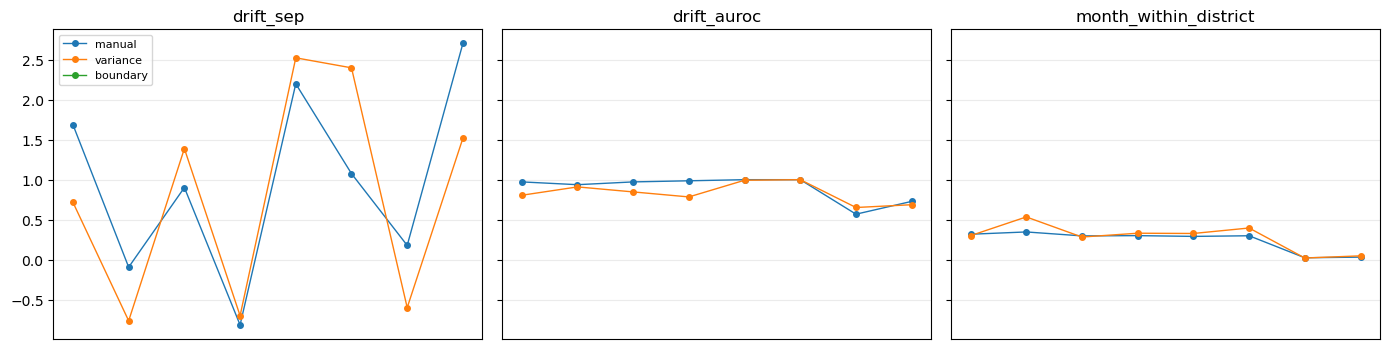

In [26]:
A = RESULTS[RESULTS["window_size"] == PREP_BASE_2["window_size"]]
for metric in ("drift_sep", "month_within_district", "sil_district"):
    print(f"-- {metric}")
    display(A.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values=metric).round(3))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for i, metric in enumerate(("drift_sep", "drift_auroc", "month_within_district")):
    for s in STRATEGIES:
        g = A[A["strategy"] == s].set_index(["transform", "scaling"])[metric]
        ax[i].plot(range(len(g)), g.to_numpy(), marker="o", ms=4, lw=1, label=s)
    ax[i].set_xticks(range(len(g)))
    ax[i].set_xticklabels([f"{a}\n{b}" for a, b in g.index], fontsize=7, rotation=0)
    ax[i].set_title(metric); ax[i].grid(alpha=.25)
ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

## 8. Across worlds

Same grid, reduced to the axis that moved on the single world, run on every usable baseline world.
The single-world ranking is a hypothesis; this is the test. Rebuilds the module-level world state
per world, so run SS.7 first and read this as the replication.

In [ ]:
GRID_MULTI = [g for g in GRID if g["prep"] is PREP_BASE]      # drop the geometry block
WORLDS_TO_RUN = usable["dir"].tolist()[:4]                    # trim to taste


def run_world(world_row, grid, cap=CAP, rounds=ROUNDS) -> pd.DataFrame:
    global ART, TIME, STEPS_DAY, FL_BASE, TRUTH_CLIENT, DRIFT_START, CLIENTS, PLACEMENTS, _WIN_CACHE
    ART = P.load_world(world_row["dir"])
    TIME, STEPS_DAY = ART["params"]["time"], ART["steps_day"]
    FL_BASE = copy.deepcopy(ART["params"].get("fl", BASE_PARAMS["fl"]))
    FL_BASE["training"]["device"] = DEVICE
    TRUTH_CLIENT = world_row.get("drift_district")
    DRIFT_START = drift_start(world_row["dir"], TIME["n_months"])

    cands = P.candidate_table(ART["wn"], ART["districts"])
    feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
    stats = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
    PLACEMENTS = {k: v for k, v in P.strategies(cands, feats, stats, dist, ART["params"],
                                                seed=SEED).items() if k in STRATEGIES}
    CLIENTS = {s: clients_from_placement(ART, pl) for s, pl in PLACEMENTS.items()}
    _WIN_CACHE = {}

    out = []
    for g in grid:
        try:
            out.append({**run_cell(**g, rounds=rounds, cap=cap),
                        "sim_hash": world_row["sim_hash"], "tag": world_row["tag"]})
        except Exception as exc:
            print(f"    {g['strategy']}/{g['transform']}/{g['scaling']} FAILED "
                  f"{type(exc).__name__}: {exc}")
    return pd.DataFrame(out)


all_rows = []
for wd in WORLDS_TO_RUN:
    w = usable[usable["dir"] == wd].iloc[0]
    t0 = time.time()
    print(f"=== {w['tag']} ({w['sim_hash'][:8]}) ===")
    all_rows.append(run_world(w, GRID_MULTI))
    print(f"    {time.time() - t0:.0f}s")

MULTI = pd.concat(all_rows, ignore_index=True)
MULTI.to_csv(OUT / "grid_multiworld.csv", index=False)
print(f"{MULTI['sim_hash'].nunique()} worlds x {len(GRID_MULTI)} cells = {len(MULTI)} rows")

In [ ]:
piv = MULTI.pivot_table(index=["transform", "scaling"], columns="strategy",
                        values=["drift_sep", "month_within_district"],
                        aggfunc=["mean", "std"]).round(3)
display(piv)

ref = MULTI[(MULTI.strategy == "manual") & (MULTI.transform == "none")
            & (MULTI.scaling == "minmax_ref")].set_index("sim_hash")
delta = []
for (s, t, k), g in MULTI.groupby(["strategy", "transform", "scaling"]):
    g = g.set_index("sim_hash")
    common = g.index.intersection(ref.index)
    if len(common) < 2:
        continue
    for metric in ("drift_sep", "drift_auroc", "month_within_district"):
        d = (g.loc[common, metric] - ref.loc[common, metric]).dropna()
        if len(d) < 2:
            continue
        delta.append(dict(strategy=s, transform=t, scaling=k, metric=metric, n=len(d),
                          mean_delta=float(d.mean()),
                          wins=int((d > 0).sum()),
                          se=float(d.std(ddof=1) / np.sqrt(len(d)))))
DELTA = pd.DataFrame(delta)
DELTA["t"] = DELTA["mean_delta"] / DELTA["se"].replace(0, np.nan)
display(DELTA[DELTA.metric == "drift_sep"].sort_values("mean_delta", ascending=False).round(3))

## 9. Reading this

Decision rules, set before looking:

- A preprocessing or placement choice is **real** only if `mean_delta > 0` with `wins` in most
  worlds and `|t| > 2` in SS.8. One world's grid orders the cells; it does not rank them.
- `drift_sep` and `month_within_district` are allowed to disagree, and probably will:
  `deseason_own` and `diff` remove the level, which is the drift signal and *not* the regime
  shape. If a cell wins on the latent metrics and loses on drift, that is the finding, not a bug
   -- it says the two downstream tasks want different preprocessing, and the FL stack currently
  serves both from one pipeline.
- `scaling=none` failing is informative: it means FedAvg cannot absorb clients on different
  physical scales, which is an argument for the commissioning-month MinMax rather than an
  accident of it.
- Read `probe_district` as a control, not a result. Near 1.0 at every cell means the client
  fingerprint dominates and the pooled month/regime probes are answered before training starts.
- The whole grid is one seed. Before anything reaches the dissertation, re-run the surviving
  cells over `training.seed` -- and note the `hash()` reproducibility hole in `sensing` and the
  surrogate RNGs, which makes back-to-back comparisons drift unless `PYTHONHASHSEED` is pinned.